In [4]:
import pandas as pd
import numpy as np

# Load the first hospital dataset
df_a = pd.read_csv('/kaggle/input/datasets/akhtar1122/patient-dataset/hospital_a_patients.csv')

# Display basic information about the dataset
print("Dataset shape:", df_a.shape)
print("\nColumn names:")
print(df_a.columns.tolist())
print("\nFirst 5 rows:")
print(df_a.head())
print("\nData types:")
print(df_a.dtypes)

Dataset shape: (25, 5)

Column names:
['patient_id', 'patient_name', 'diagnosis', 'outcome', 'length_of_stay']

First 5 rows:
   patient_id  patient_name      diagnosis   outcome  length_of_stay
0        1000  Patient_1000      Pneumonia  Deceased               7
1        1001  Patient_1001         Asthma  Deceased               2
2        1002  Patient_1002  Heart Disease  Deceased               4
3        1003  Patient_1003         Asthma  Improved               9
4        1004  Patient_1004         Asthma  Referred              12

Data types:
patient_id         int64
patient_name      object
diagnosis         object
outcome           object
length_of_stay     int64
dtype: object


In [6]:
# Load all hospital datasets
hospital_files = [
    '/kaggle/input/datasets/akhtar1122/patient-dataset/hospital_a_patients.csv',
    '/kaggle/input/datasets/akhtar1122/patient-dataset/hospital_b_patients.csv', 
    '/kaggle/input/datasets/akhtar1122/patient-dataset/hospital_c_patients.csv'
]

# Store datasets in a list
hospital_datasets = []

for file in hospital_files:
    df = pd.read_csv(file)
    print(f"Loaded {file}: {df.shape[0]} rows, {df.shape[1]} columns")
    hospital_datasets.append(df)

Loaded /kaggle/input/datasets/akhtar1122/patient-dataset/hospital_a_patients.csv: 25 rows, 5 columns
Loaded /kaggle/input/datasets/akhtar1122/patient-dataset/hospital_b_patients.csv: 25 rows, 5 columns
Loaded /kaggle/input/datasets/akhtar1122/patient-dataset/hospital_c_patients.csv: 25 rows, 5 columns


In [7]:
# Compare column names across hospitals
for i, df in enumerate(hospital_datasets):
    print(f"\nHospital {chr(65+i)} columns:")
    print(df.columns.tolist())


Hospital A columns:
['patient_id', 'patient_name', 'diagnosis', 'outcome', 'length_of_stay']

Hospital B columns:
['patient_id', 'patient_name', 'diagnosis', 'outcome', 'length_of_stay']

Hospital C columns:
['patient_id', 'patient_name', 'diagnosis', 'outcome', 'length_of_stay']


In [8]:
# Check for missing values in each dataset
for i, df in enumerate(hospital_datasets):
    print(f"\nHospital {chr(65+i)} missing values:")
    print(df.isnull().sum())


Hospital A missing values:
patient_id        0
patient_name      0
diagnosis         0
outcome           0
length_of_stay    0
dtype: int64

Hospital B missing values:
patient_id        0
patient_name      0
diagnosis         0
outcome           0
length_of_stay    0
dtype: int64

Hospital C missing values:
patient_id        0
patient_name      0
diagnosis         0
outcome           0
length_of_stay    0
dtype: int64


In [9]:
def clean_column_names(df):
    """
    Clean column names by:
    - Converting to lowercase
    - Replacing spaces with underscores
    - Removing special characters
    """
    df.columns = df.columns.str.lower()
    df.columns = df.columns.str.replace(' ', '_')
    df.columns = df.columns.str.replace('[^a-zA-Z0-9_]', '', regex=True)
    return df

# Apply column cleaning to all datasets
cleaned_datasets = []
for i, df in enumerate(hospital_datasets):
    cleaned_df = clean_column_names(df.copy())
    print(f"Hospital {chr(65+i)} cleaned columns:")
    print(cleaned_df.columns.tolist())
    cleaned_datasets.append(cleaned_df)

Hospital A cleaned columns:
['patient_id', 'patient_name', 'diagnosis', 'outcome', 'length_of_stay']
Hospital B cleaned columns:
['patient_id', 'patient_name', 'diagnosis', 'outcome', 'length_of_stay']
Hospital C cleaned columns:
['patient_id', 'patient_name', 'diagnosis', 'outcome', 'length_of_stay']


In [10]:
# Add hospital identifier to each dataset
for i, df in enumerate(cleaned_datasets):
    df['hospital_id'] = chr(65+i)  # A, B, C

# Merge all datasets
merged_emr_data = pd.concat(cleaned_datasets, ignore_index=True)

print(f"Merged dataset shape: {merged_emr_data.shape}")
print(f"Total patients across all hospitals: {merged_emr_data.shape[0]}")
print("\nHospital distribution:")
print(merged_emr_data['hospital_id'].value_counts())

Merged dataset shape: (75, 6)
Total patients across all hospitals: 75

Hospital distribution:
hospital_id
A    25
B    25
C    25
Name: count, dtype: int64


In [11]:
# Display first few rows to understand the data structure
print("Sample of merged data:")
print(merged_emr_data.head())

# Check for duplicates based on patient ID
print(f"\nTotal records: {len(merged_emr_data)}")
print(f"Unique patient IDs: {merged_emr_data['patient_id'].nunique()}")
print(f"Duplicate records: {len(merged_emr_data) - merged_emr_data['patient_id'].nunique()}")

Sample of merged data:
   patient_id  patient_name      diagnosis   outcome  length_of_stay  \
0        1000  Patient_1000      Pneumonia  Deceased               7   
1        1001  Patient_1001         Asthma  Deceased               2   
2        1002  Patient_1002  Heart Disease  Deceased               4   
3        1003  Patient_1003         Asthma  Improved               9   
4        1004  Patient_1004         Asthma  Referred              12   

  hospital_id  
0           A  
1           A  
2           A  
3           A  
4           A  

Total records: 75
Unique patient IDs: 65
Duplicate records: 10


In [12]:
# Find duplicate patient IDs
duplicate_patients = merged_emr_data[merged_emr_data.duplicated(subset=['patient_id'], keep=False)]

if len(duplicate_patients) > 0:
    print("Sample duplicate records:")
    print(duplicate_patients.sort_values('patient_id').head(10))
else:
    print("No duplicate patient IDs found")

Sample duplicate records:
    patient_id  patient_name     diagnosis    outcome  length_of_stay  \
20        1020  Patient_1020  Hypertension  Recovered              14   
25        1020  Patient_1020     Pneumonia   Deceased              12   
26        1021  Patient_1021  Hypertension  Recovered               7   
21        1021  Patient_1021        Asthma   Deceased               1   
27        1022  Patient_1022  Hypertension  Recovered               9   
22        1022  Patient_1022     Pneumonia   Deceased               4   
23        1023  Patient_1023      Diabetes  Recovered               2   
28        1023  Patient_1023     Pneumonia  Recovered               8   
24        1024  Patient_1024      Diabetes  Recovered               8   
29        1024  Patient_1024        Asthma   Deceased              12   

   hospital_id  
20           A  
25           B  
26           B  
21           A  
27           B  
22           A  
23           A  
28           B  
24           A  


In [13]:
# Remove duplicates keeping the first occurrence
print(f"Before duplicate removal: {len(merged_emr_data)} records")

# Remove duplicates based on patient_id, keeping first occurrence
clean_emr_data = merged_emr_data.drop_duplicates(subset=['patient_id'], keep='first')

print(f"After duplicate removal: {len(clean_emr_data)} records")
print(f"Removed {len(merged_emr_data) - len(clean_emr_data)} duplicate records")

Before duplicate removal: 75 records
After duplicate removal: 65 records
Removed 10 duplicate records


In [14]:
# Confirm no duplicates remain
remaining_duplicates = clean_emr_data['patient_id'].duplicated().sum()
print(f"Remaining duplicate patient IDs: {remaining_duplicates}")

# Display final dataset summary
print(f"\nFinal clean dataset:")
print(f"Shape: {clean_emr_data.shape}")
print(f"Unique patients: {clean_emr_data['patient_id'].nunique()}")

Remaining duplicate patient IDs: 0

Final clean dataset:
Shape: (65, 6)
Unique patients: 65


In [15]:
# Check diagnosis column
print("Available diagnoses:")
diagnosis_counts = clean_emr_data['diagnosis'].value_counts()
print(diagnosis_counts)

print(f"\nTotal unique diagnoses: {clean_emr_data['diagnosis'].nunique()}")

Available diagnoses:
diagnosis
Asthma           19
Pneumonia        17
Hypertension     12
Heart Disease     9
Diabetes          8
Name: count, dtype: int64

Total unique diagnoses: 5


In [16]:
# Define diagnoses of interest for our analysis
target_diagnoses = ['Diabetes', 'Hypertension', 'Heart Disease', 'Pneumonia']

# Check which target diagnoses exist in our data
available_targets = []
for diagnosis in target_diagnoses:
    count = clean_emr_data['diagnosis'].str.contains(diagnosis, case=False, na=False).sum()
    if count > 0:
        available_targets.append(diagnosis)
        print(f"{diagnosis}: {count} patients")

print(f"\nAvailable target diagnoses: {available_targets}")

Diabetes: 8 patients
Hypertension: 12 patients
Heart Disease: 9 patients
Pneumonia: 17 patients

Available target diagnoses: ['Diabetes', 'Hypertension', 'Heart Disease', 'Pneumonia']


In [17]:
# Filter for patients with target diagnoses
if available_targets:
    # Create a pattern to match any of the target diagnoses
    pattern = '|'.join(available_targets)
    filtered_emr_data = clean_emr_data[
        clean_emr_data['diagnosis'].str.contains(pattern, case=False, na=False)
    ]
else:
    # If no target diagnoses found, use top 3 most common diagnoses
    top_diagnoses = diagnosis_counts.head(3).index.tolist()
    pattern = '|'.join(top_diagnoses)
    filtered_emr_data = clean_emr_data[
        clean_emr_data['diagnosis'].str.contains(pattern, case=False, na=False)
    ]
    print(f"Using top diagnoses: {top_diagnoses}")

print(f"\nFiltered dataset:")
print(f"Original records: {len(clean_emr_data)}")
print(f"Filtered records: {len(filtered_emr_data)}")
print(f"Percentage retained: {len(filtered_emr_data)/len(clean_emr_data)*100:.1f}%")


Filtered dataset:
Original records: 65
Filtered records: 46
Percentage retained: 70.8%


In [18]:
# Check diagnosis distribution in filtered data
print("\nDiagnosis distribution in filtered data:")
print(filtered_emr_data['diagnosis'].value_counts())

# Display sample of filtered data
print("\nSample of filtered data:")
print(filtered_emr_data[['patient_id', 'diagnosis', 'outcome', 'length_of_stay']].head())


Diagnosis distribution in filtered data:
diagnosis
Pneumonia        17
Hypertension     12
Heart Disease     9
Diabetes          8
Name: count, dtype: int64

Sample of filtered data:
   patient_id      diagnosis   outcome  length_of_stay
0        1000      Pneumonia  Deceased               7
2        1002  Heart Disease  Deceased               4
5        1005   Hypertension  Referred              14
6        1006  Heart Disease  Referred               2
7        1007  Heart Disease  Referred              10


In [19]:
# Check available outcomes
print("Patient outcomes:")
outcome_counts = filtered_emr_data['outcome'].value_counts()
print(outcome_counts)

# Check for missing outcome data
missing_outcomes = filtered_emr_data['outcome'].isnull().sum()
print(f"\nMissing outcome data: {missing_outcomes}")


Patient outcomes:
outcome
Deceased     14
Recovered    13
Referred     11
Improved      8
Name: count, dtype: int64

Missing outcome data: 0


In [20]:
# Handle missing outcomes if any
if missing_outcomes > 0:
    print("Removing records with missing outcomes...")
    filtered_emr_data = filtered_emr_data.dropna(subset=['outcome'])
    print(f"Records after removing missing outcomes: {len(filtered_emr_data)}")

In [21]:
# Check length_of_stay column
print("Length of stay statistics:")
print(filtered_emr_data['length_of_stay'].describe())

# Check for missing or invalid values
missing_los = filtered_emr_data['length_of_stay'].isnull().sum()
negative_los = (filtered_emr_data['length_of_stay'] < 0).sum()

print(f"\nMissing length of stay: {missing_los}")
print(f"Negative length of stay: {negative_los}")


Length of stay statistics:
count    46.000000
mean      6.891304
std       4.433350
min       1.000000
25%       3.000000
50%       7.000000
75%      10.750000
max      14.000000
Name: length_of_stay, dtype: float64

Missing length of stay: 0
Negative length of stay: 0


In [22]:
# Remove records with missing or invalid length of stay
valid_los_data = filtered_emr_data[
    (filtered_emr_data['length_of_stay'].notnull()) & 
    (filtered_emr_data['length_of_stay'] >= 0)
]

print(f"Records with valid length of stay: {len(valid_los_data)}")

# Check for outliers
q75, q25 = np.percentile(valid_los_data['length_of_stay'], [75, 25])
iqr = q75 - q25
upper_bound = q75 + (1.5 * iqr)

outliers = valid_los_data[valid_los_data['length_of_stay'] > upper_bound]
print(f"Potential outliers (stay > {upper_bound:.1f} days): {len(outliers)}")

Records with valid length of stay: 46
Potential outliers (stay > 22.4 days): 0


In [23]:
# Group by outcome and calculate average length of stay
outcome_analysis = valid_los_data.groupby('outcome')['length_of_stay'].agg([
    'count',    # Number of patients
    'mean',     # Average length of stay
    'median',   # Median length of stay
    'std',      # Standard deviation
    'min',      # Minimum stay
    'max'       # Maximum stay
]).round(2)

print("Length of Stay Analysis by Patient Outcome:")
print("=" * 50)
print(outcome_analysis)

Length of Stay Analysis by Patient Outcome:
           count  mean  median   std  min  max
outcome                                       
Deceased      14  5.50     4.0  3.86    1   14
Improved       8  7.25     6.5  5.18    1   14
Recovered     13  6.54     7.0  4.41    1   14
Referred      11  8.82    10.0  4.47    1   14


In [24]:
# More detailed analysis: group by both diagnosis and outcome
detailed_analysis = valid_los_data.groupby(['diagnosis', 'outcome'])['length_of_stay'].agg([
    'count',
    'mean'
]).round(2)

print("\n\nDetailed Analysis by Diagnosis and Outcome:")
print("=" * 55)
print(detailed_analysis)



Detailed Analysis by Diagnosis and Outcome:
                         count   mean
diagnosis     outcome                
Diabetes      Deceased       1   3.00
              Improved       2   3.00
              Recovered      5   6.20
Heart Disease Deceased       3   5.00
              Improved       1  14.00
              Recovered      3   5.33
              Referred       2   6.00
Hypertension  Deceased       3   7.33
              Improved       1   1.00
              Recovered      3   8.67
              Referred       5   8.40
Pneumonia     Deceased       7   5.29
              Improved       4   9.25
              Recovered      2   6.00
              Referred       4  10.75


In [25]:
# Generate final summary report
print("\n" + "="*60)
print("EMR DATA ANALYSIS SUMMARY REPORT")
print("="*60)

print(f"\nDATA PROCESSING SUMMARY:")
print(f"• Original records loaded: {len(merged_emr_data)}")
print(f"• Records after duplicate removal: {len(clean_emr_data)}")
print(f"• Records after diagnosis filtering: {len(filtered_emr_data)}")
print(f"• Records with valid length of stay: {len(valid_los_data)}")

print(f"\nKEY FINDINGS:")
for outcome in outcome_analysis.index:
    count = outcome_analysis.loc[outcome, 'count']
    avg_stay = outcome_analysis.loc[outcome, 'mean']
    print(f"• {outcome}: {count} patients, average stay {avg_stay} days")

# Find outcome with longest average stay
longest_stay_outcome = outcome_analysis['mean'].idxmax()
longest_stay_days = outcome_analysis.loc[longest_stay_outcome, 'mean']

print(f"\nCRITICAL INSIGHT:")
print(f"• Patients with '{longest_stay_outcome}' outcome have the longest average stay: {longest_stay_days} days")


EMR DATA ANALYSIS SUMMARY REPORT

DATA PROCESSING SUMMARY:
• Original records loaded: 75
• Records after duplicate removal: 65
• Records after diagnosis filtering: 46
• Records with valid length of stay: 46

KEY FINDINGS:
• Deceased: 14 patients, average stay 5.5 days
• Improved: 8 patients, average stay 7.25 days
• Recovered: 13 patients, average stay 6.54 days
• Referred: 11 patients, average stay 8.82 days

CRITICAL INSIGHT:
• Patients with 'Referred' outcome have the longest average stay: 8.82 days


In [26]:
# Save the analysis results
outcome_analysis.to_csv('emr_outcome_analysis.csv')
detailed_analysis.to_csv('emr_detailed_analysis.csv')

print(f"\nResults saved to:")
print(f"• emr_outcome_analysis.csv")
print(f"• emr_detailed_analysis.csv")

# Exit Python
# exit()


Results saved to:
• emr_outcome_analysis.csv
• emr_detailed_analysis.csv


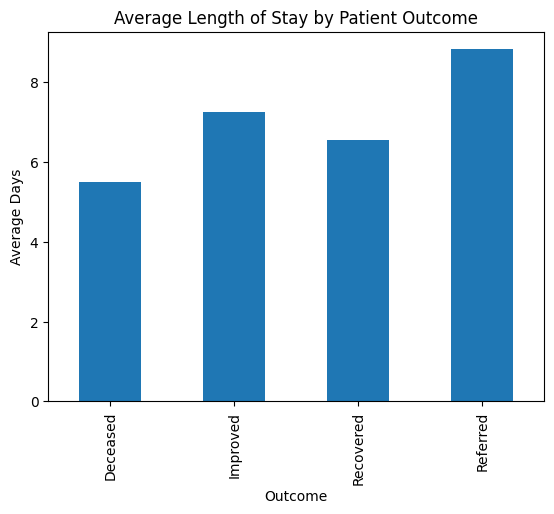

In [27]:
import matplotlib.pyplot as plt

outcome_analysis['mean'].plot(kind='bar')

plt.title("Average Length of Stay by Patient Outcome")
plt.xlabel("Outcome")
plt.ylabel("Average Days")

plt.show()

#This project demonstrates a complete healthcare data analysis workflow
using simulated Electronic Medical Record (EMR) datasets.

Key tasks performed:
• Cleaning and merging hospital datasets
• Removing duplicate patient records
• Standardizing column names
• Filtering patients by diagnosis
• Grouping by outcomes to analyze average hospital stay

Tools Used:
Python, Pandas, NumPy, Matplotlib